# Setup Imports

In [1]:
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 22.2 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 37.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 45.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 45.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 50.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 24.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 40.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load the dataset 

In [4]:
# The file yeast.csv was downloaded from https://www.kaggle.com/datasets/samanemami/yeastcsv?resource=download 

# Load the CSV file
df = pd.read_csv("yeast.csv")

# View first few rows
df.head()


,mcg,gvh,alm,mit,erl,pox,vac,nuc,name
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


# Exploratory Data Analysis

## Inspect the dataframe

In [10]:
# Shape of the dataframe (rows, columns)
df.shape

(1484, 9)

In [8]:
# Data types and non-null counts for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     1484 non-null   float64
 1   gvh     1484 non-null   float64
 2   alm     1484 non-null   float64
 3   mit     1484 non-null   float64
 4   erl     1484 non-null   float64
 5   pox     1484 non-null   float64
 6   vac     1484 non-null   float64
 7   nuc     1484 non-null   float64
 8   name    1484 non-null   str    
dtypes: float64(8), str(1)
memory usage: 104.5 KB


In [11]:
# Summary statistics for numeric columns
df.describe()

,mcg,gvh,alm,mit,erl,pox,vac,nuc
count,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000
mean,0.500121,0.499933,0.500034,0.261186,0.504717,0.007500,0.499885,0.276199
std,0.137299,0.123924,0.086670,0.137098,0.048351,0.075683,0.057797,0.106491
min,0.110000,0.130000,0.210000,0.000000,0.500000,0.000000,0.000000,0.000000
25%,0.410000,0.420000,0.460000,0.170000,0.500000,0.000000,0.480000,0.220000
50%,0.490000,0.490000,0.510000,0.220000,0.500000,0.000000,0.510000,0.220000
75%,0.580000,0.570000,0.550000,0.320000,0.500000,0.000000,0.530000,0.300000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.830000,0.730000,1.000000


## Class Distribution

In [14]:
# Count of proteins in each localization class
df["name"].value_counts()

name
CYT    463
NUC    429
MIT    244
ME3    163
ME2     51
ME1     44
EXC     35
VAC     30
POX     20
ERL      5
Name: count, dtype: int64

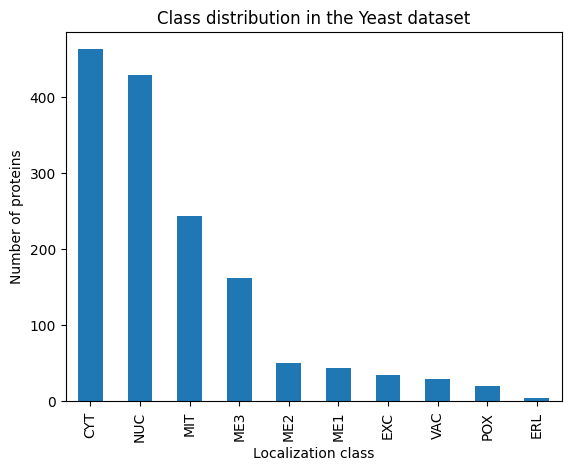

In [15]:
# Bar chart of class distribution
df["name"].value_counts().plot(kind="bar")
plt.xlabel("Localization class")
plt.ylabel("Number of proteins")
plt.title("Class distribution in the Yeast dataset")
plt.show()

### Note that ERL having only 5 samples is going to be an issue for analysis

# Data Preprocessing


## Handle Missing Values

In [16]:
# Check for missing values in each column
df.isna().sum()

mcg     0
gvh     0
alm     0
mit     0
erl     0
pox     0
vac     0
nuc     0
name    0
dtype: int64

In [ ]:
# No missing values were found, so no rows need to be dropped.
# We still create df_clean here so later sections operate on a dedicated
# preprocessed dataframe (rather than the raw df).
df_clean = df.dropna().copy()

print("Original shape:", df.shape)
print("Shape after dropping any missing rows:", df_clean.shape)

#If missing values had been present, options would have included dropping rows (dropna), filling with column means (fillna), or interpolation (interpolate)

Original shape: (1484, 9)
Shape after dropping any missing rows: (1484, 9)


## Separate Features and Target

In [20]:

# Separate features from the target.
# The first 8 columns (mcg, gvh, alm, mit, erl, pox, vac, nuc) are features.
# The final column 'name' is the target (localization class).
X = df_clean.iloc[:, :-1]   # all columns except the last
y = df_clean.iloc[:, -1]    # the last column

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:", list(X.columns))

Feature shape: (1484, 8)
Target shape: (1484,)

Features: ['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']


## Scale Features

In [25]:
# Standardize features to zero mean and unit variance.
# This matters for distance-based models (KNN, and Bagging with KNN as the base learner).
# Tree-based models (Random Forest, AdaBoost) are scale-invariant and use the unscaled X.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verification
print("Mean of scaled features (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std of scaled features (should be ~1):", X_scaled.std(axis=0).round(3))

Mean of scaled features (should be ~0): [ 0.  0.  0.  0. -0.  0.  0.  0.]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## Train/Test Split

In [ ]:
# Train/test split. We create both an unscaled split (for tree-based models)
# and a scaled split (for distance-based models) using the same indices,
# guaranteed by using the same random_state.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (1187, 8)
X_test shape: (297, 8)

Training class distribution:
name
CYT    370
NUC    343
MIT    195
ME3    131
ME2     41
ME1     35
EXC     28
VAC     24
POX     16
ERL      4
Name: count, dtype: int64

Test class distribution:
name
CYT    93
NUC    86
MIT    49
ME3    32
ME2    10
ME1     9
EXC     7
VAC     6
POX     4
ERL     1
Name: count, dtype: int64


# Random Forest Model